In [1]:
import os
os.environ['HF_DATASETS_OFFLINE'] = '1'
os.environ['HF_EVALUATE_OFFLINE'] = '1'
os.environ['TRANSFORMERS_OFFLINE'] = '1'

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import faiss
import numpy as np
import pickle
import json
import math
import re
import random
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from transformers import AutoTokenizer, T5EncoderModel, AutoModelForCausalLM

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_LOCAL_PATH = './gtr-t5-base-local'
CMD_CKPT         = './cmd_checkpoints_small'
LM_PATH          = './gpt2_local'

print(f'PyTorch  : {torch.__version__}')
print(f'FAISS    : {faiss.__version__}')
print(f'Device   : {device}')

/home/pmd4nd/.conda/envs/privacy_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch  : 2.4.1+cu121
FAISS    : 1.13.2
Device   : cuda


# Phase 3: Defense Evaluation

**Goal**: Measure how two defenses — **Laplace Differential Privacy (DP)** and **Scalar Quantization** — degrade the attack fidelity established in Phase 2, while tracking the cost to RAG retrieval utility.

**The Privacy-Utility Frontier**

Every defense we apply creates a trade-off:
- 🔒 **Privacy Gain** — Attack metrics (BLEU, ROUGE-L, Token Accuracy, Cosine Similarity) should drop as defenses get stronger.
- 📉 **Utility Cost** — Retrieval accuracy (Top-1 and Top-5 recall in FAISS) will also degrade as we distort vectors.

We want to find the **"elbow"** — where maximum privacy gain meets minimum utility loss.

| Defense | Parameter | Range |
|---|---|---|
| Laplace Noise (DP) | Privacy budget ε | 0.1, 0.5, 1.0, 2.0, 5.0, 10.0 |
| Scalar Quantization | Bit depth | 4-bit, 8-bit (FP32 baseline) |

For each configuration, we re-run both the **Vec2Text beam attack** and the **CMD attack** on 200 held-out evaluation samples.

---
## 3.0 — Load All Phase 1 & 2 Artifacts

In [3]:
# ── Texts ────────────────────────────────────────────────────────────────────
with open('processed_pii_texts.pkl', 'rb') as f:
    texts_for_db = pickle.load(f)
print(f'PII texts loaded  : {len(texts_for_db):,}')

# ── Raw embeddings ─────────────────────────────────────────────────────────
vectors = np.load('embeddings.npy').astype('float32')
print(f'Embeddings shape  : {vectors.shape}')

# ── GTR-T5 encoder ──────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_LOCAL_PATH)
gtr_model = T5EncoderModel.from_pretrained(MODEL_LOCAL_PATH).to(device).eval()
print('GTR-T5 encoder ready.')

# ── Evaluation split — last 200 samples, same as Phase 2 ────────────────────
N_EVAL       = 200
eval_texts   = texts_for_db[-N_EVAL:]
eval_vectors = vectors[-N_EVAL:]   # (200, 768) numpy float32
eval_vectors_np = vectors[-N_EVAL:]  # numpy float32, for noise/retrieval functions
print(f'Eval set          : {N_EVAL} samples')

PII texts loaded  : 43,000
Embeddings shape  : (43000, 768)


Loading weights: 100%|██████████| 99/99 [00:00<00:00, 24888.28it/s]


GTR-T5 encoder ready.
Eval set          : 200 samples


## 3.1 — Rebuild Exact Phase 2 Models

### 3.1.1 Vec2Text Attack — Exact Phase 2 Functions

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  Vec2Text helpers — verbatim from Phase 2
# ─────────────────────────────────────────────────────────────────────────────

def is_clean(text):
    if not text or not text.strip(): return False
    if re.search(r'<[^>]+>', text): return False
    if re.search(r'&lt;|&gt;|\\u003', text): return False
    if len(text.strip()) < 8: return False
    non_ascii = sum(1 for c in text if ord(c) > 127)
    if non_ascii / max(len(text), 1) > 0.15: return False
    if re.search(r'(\b\S+\b)(\s+\1){4,}', text): return False
    if len(re.findall(r'\[\d+\]', text)) >= 4: return False
    return True

def structure_penalty(text):
    penalty = 0.0
    if re.search(r'\(\d+\).*\(\d+\).*\(\d+\)', text): penalty += 0.15
    if re.search(r'§\s*\d+[-–]\d+', text): penalty += 0.10
    if len(re.findall(r'\d+\)', text)) >= 3: penalty += 0.12
    if text.lower().count('section') >= 3: penalty += 0.10
    if len(re.findall(r'\b\d+\b', text)) >= 6: penalty += 0.12
    return penalty

def get_embedding(text, emb_model, emb_tokenizer, device='cuda'):
    inputs = emb_tokenizer(
        text, return_tensors='pt', padding='max_length', max_length=32, truncation=True
    ).to(device)
    with torch.no_grad():
        emb = emb_model.encoder(**inputs).last_hidden_state.mean(dim=1)
    return F.normalize(emb, dim=-1)

def get_lm_score(text, lm_model, lm_tokenizer, device='cuda', max_len=64):
    if not text.strip(): return -10.0
    inputs = lm_tokenizer(text, return_tensors='pt', truncation=True, max_length=max_len).to(device)
    if inputs.input_ids.shape[1] < 2: return -10.0
    with torch.no_grad():
        outputs = lm_model(inputs.input_ids, labels=inputs.input_ids)
    return -outputs.loss.item()

# ── Cap GPT-2 generation length to avoid 512-token overflow ──────────────────
def get_fluent_candidates(prefix, lm_model, lm_tokenizer, n=4, device='cuda'):
    inputs = lm_tokenizer(prefix, return_tensors='pt',
                          truncation=True, max_length=60).to(device)
    with torch.no_grad():
        outputs = lm_model.generate(
            **inputs, max_new_tokens=20, do_sample=True,
            temperature=0.9, top_p=0.95, num_return_sequences=n,
            pad_token_id=lm_tokenizer.eos_token_id,
        )
    raw = [lm_tokenizer.decode(o, skip_special_tokens=True).strip() for o in outputs]
    return [t for t in raw if is_clean(t)]

def get_fluent_candidates_diverse(lm_model, lm_tokenizer, n=2, device='cuda'):
    seeds = ['The', 'My name is', 'She was', 'According to', 'He said that', 'They found']
    results = []
    for seed in random.sample(seeds, min(n, len(seeds))):
        inputs = lm_tokenizer(seed, return_tensors='pt').to(device)
        with torch.no_grad():\
            out = lm_model.generate(
                **inputs, max_new_tokens=20, do_sample=True,
                temperature=1.3, top_p=0.95, num_return_sequences=1,
                pad_token_id=lm_tokenizer.eos_token_id,
            )
        text = lm_tokenizer.decode(out[0], skip_special_tokens=True).strip()
        if is_clean(text): results.append(text)
    return results

def paraphrase_candidates(text, lm_model, lm_tokenizer, n=2, device='cuda'):
    prompt = f'Rephrase: {text}\nRephrasing:'
    inputs = lm_tokenizer(prompt, return_tensors='pt',
                          truncation=True, max_length=80).to(device)
    with torch.no_grad():
        outputs = lm_model.generate(
            **inputs, max_new_tokens=20, do_sample=True,
            temperature=1.1, top_p=0.9, num_return_sequences=n,
            pad_token_id=lm_tokenizer.eos_token_id,
        )
    results = []
    for o in outputs:
        decoded  = lm_tokenizer.decode(o, skip_special_tokens=True)
        text_out = decoded.split('Rephrasing:')[-1].strip() if 'Rephrasing:' in decoded else decoded
        if is_clean(text_out): results.append(text_out)
    return results

print('GPT-2 generation helpers patched (max_new_tokens=20).')

def build_clean_vocab_mask(emb_model, emb_tokenizer, device='cuda'):
    actual_vocab_size = emb_model.shared.weight.shape[0]
    mask = torch.zeros(actual_vocab_size, dtype=torch.bool, device=device)
    for tok_id in range(actual_vocab_size):
        tok_str = emb_tokenizer.decode([tok_id])
        if not tok_str: continue
        if any(ord(c) > 127 for c in tok_str): continue
        if re.search(r'<[^>]+>', tok_str): continue
        mask[tok_id] = True
    return mask

def word_level_hotflip(text, emb_model, emb_tokenizer, target_vec,
                        top_k=5, vocab_mask=None, device='cuda'):
    words = text.split()
    if not words: return text
    best_text = text
    best_sim  = F.cosine_similarity(
        get_embedding(text, emb_model, emb_tokenizer, device), target_vec, dim=-1
    ).item()
    with torch.no_grad():
        norm_vocab = F.normalize(emb_model.shared.weight, dim=-1)
    for i, word in enumerate(words):
        word_inputs = emb_tokenizer(word, return_tensors='pt').to(device)
        with torch.no_grad():
            word_emb = emb_model.shared(word_inputs.input_ids).mean(dim=1)
        norm_word = F.normalize(word_emb, dim=-1)
        sims      = (norm_word @ norm_vocab.T).squeeze()
        if vocab_mask is not None:
            sims = sims.masked_fill(~vocab_mask, -1e9)
        top_ids = sims.topk(top_k).indices
        for tok_id in top_ids:
            candidate_word = emb_tokenizer.decode([tok_id.item()]).strip()
            if not candidate_word or candidate_word == word: continue
            new_text = ' '.join(words[:i] + [candidate_word] + words[i+1:])
            if not is_clean(new_text): continue
            new_sim = F.cosine_similarity(
                get_embedding(new_text, emb_model, emb_tokenizer, device),
                target_vec, dim=-1
            ).item()
            if new_sim > best_sim:
                best_sim  = new_sim
                best_text = new_text
                words     = best_text.split()
                break
    return best_text


def generate_initial_guess(target_vec, model, tokenizer,
                            n_tokens=16, top_k=50, steps=200, device='cuda'):
    actual_vocab_size = model.shared.weight.shape[0]
    clean_ids = []
    for tok_id in range(actual_vocab_size):
        tok_str = tokenizer.decode([tok_id])
        if not tok_str or not tok_str.strip(): continue
        if any(ord(c) > 127 for c in tok_str): continue
        if re.search(r'<[^>]+>', tok_str): continue
        clean_ids.append(tok_id)
    clean_ids = torch.tensor(clean_ids, device=device)
    with torch.no_grad():
        clean_vecs = F.normalize(model.shared.weight[clean_ids], dim=-1)

    def seq_embedding(token_ids):
        ids_tensor = torch.tensor(token_ids, device=device).unsqueeze(0)
        pad_len = 32 - len(token_ids)
        if pad_len > 0:
            pad_ids    = torch.full((1, pad_len), tokenizer.pad_token_id or 0, device=device)
            ids_tensor = torch.cat([ids_tensor, pad_ids], dim=1)
        ids_tensor = ids_tensor[:, :32]
        attn = (ids_tensor != (tokenizer.pad_token_id or 0)).long()
        with torch.no_grad():
            emb = model.encoder(input_ids=ids_tensor, attention_mask=attn).last_hidden_state.mean(dim=1)
        return F.normalize(emb, dim=-1)

    token_ids = []
    for pos in range(n_tokens):
        best_tok, best_sim = clean_ids[0].item(), -float('inf')
        tok_sims   = (clean_vecs @ target_vec.T).squeeze()
        topk_local = tok_sims.topk(top_k).indices
        for local_idx in topk_local:
            candidate_tok = clean_ids[local_idx.item()].item()
            candidate_ids = token_ids + [candidate_tok]
            sim = F.cosine_similarity(seq_embedding(candidate_ids), target_vec, dim=-1).item()
            if sim > best_sim:
                best_sim = sim
                best_tok = candidate_tok
        token_ids.append(best_tok)

    current_sim = F.cosine_similarity(seq_embedding(token_ids), target_vec, dim=-1).item()
    for _ in range(steps):
        improved = False
        for pos in range(len(token_ids)):
            original_tok = token_ids[pos]
            tok_sims     = (clean_vecs @ target_vec.T).squeeze()
            topk_local   = tok_sims.topk(top_k).indices
            for local_idx in topk_local:
                candidate_tok = clean_ids[local_idx.item()].item()
                if candidate_tok == original_tok: continue
                trial_ids = token_ids[:pos] + [candidate_tok] + token_ids[pos+1:]
                trial_sim = F.cosine_similarity(seq_embedding(trial_ids), target_vec, dim=-1).item()
                if trial_sim > current_sim:
                    token_ids   = trial_ids
                    current_sim = trial_sim
                    improved    = True
                    break
        if not improved: break

    return tokenizer.decode(token_ids, skip_special_tokens=True), current_sim


def vec2text_beam_attack_v2(target_vec, model, tokenizer,
                             lm_model=None, lm_tokenizer=None,
                             initial_guess='', beam_width=6, steps=300,
                             fluency_weight=0.15, restart_every=20,
                             device='cuda', verbose=False):
    use_lm     = (lm_model is not None) and (lm_tokenizer is not None)
    vocab_mask = build_clean_vocab_mask(model, tokenizer, device=device)

    if initial_guess and is_clean(initial_guess):
        candidates = [initial_guess]
    elif use_lm:
        candidates = get_fluent_candidates('The', lm_model, lm_tokenizer, n=beam_width, device=device)
    else:
        candidates = ['The person said']
    candidates = [c for c in candidates if is_clean(c)] or ['The person said']

    best_score, best_text, no_improve = -float('inf'), candidates[0], 0

    for step in range(steps):
        all_successors = []
        if use_lm and step > 0 and step % restart_every == 0:
            all_successors.extend(get_fluent_candidates_diverse(lm_model, lm_tokenizer, n=2, device=device))
        for text in candidates:
            if use_lm:
                words  = text.split()
                prefix = ' '.join(words[:max(3, len(words) // 2)])
                all_successors.extend(get_fluent_candidates(prefix, lm_model, lm_tokenizer, n=3, device=device))
                all_successors.extend(paraphrase_candidates(text, lm_model, lm_tokenizer, n=2, device=device))
            flipped = word_level_hotflip(text, model, tokenizer, target_vec,
                                          top_k=5, vocab_mask=vocab_mask, device=device)
            if is_clean(flipped): all_successors.append(flipped)
            all_successors.append(text)

        all_successors = [t for t in all_successors if is_clean(t)] or candidates
        scored, seen = [], set()
        for cand in all_successors:
            cand = cand.strip()
            if not cand or cand in seen: continue
            seen.add(cand)
            cand_vec = get_embedding(cand, model, tokenizer, device)
            sim      = F.cosine_similarity(cand_vec, target_vec, dim=-1).item()
            fluency  = get_lm_score(cand, lm_model, lm_tokenizer, device) if use_lm else 0.0
            penalty  = structure_penalty(cand)
            scored.append((sim + fluency_weight * fluency - penalty, sim, cand))
        scored.sort(key=lambda x: x[0], reverse=True)

        selected, present = [], set()
        for _, _, cand in scored:
            if len(selected) >= beam_width: break
            cand_vec    = get_embedding(cand, model, tokenizer, device)
            too_similar = any(
                F.cosine_similarity(cand_vec, get_embedding(prev, model, tokenizer, device)).item() > 0.90
                for prev in selected
            )
            if not too_similar: selected.append(cand)
        present = set(selected)
        for _, _, cand in scored:
            if len(selected) >= beam_width: break
            if cand not in present:
                selected.append(cand); present.add(cand)
        candidates = selected if selected else candidates

        if scored:
            _, top_sim, top_cand = max(scored, key=lambda x: x[1])
            if top_sim > best_score:
                best_score, best_text, no_improve = top_sim, top_cand, 0
            else:
                no_improve += 1
        if no_improve >= 40: break

    return best_text, best_score


print('Vec2Text functions defined.')

GPT-2 generation helpers patched (max_new_tokens=20).
Vec2Text functions defined.


### 3.1.2 CMD Model — Exact Phase 2 Definition

`ConditionalMaskedDiffusionLM` instantiated with the same hyperparameters used in Phase 2 training: `hidden_dim=512, num_layers=4, num_heads=8, ffn_dim=1024`.

In [5]:
class LogLinearNoiseSchedule:
    def __init__(self, lam=5.0):
        self.lam = lam
    def alpha(self, t):
        return torch.exp(-self.lam * t)
    def sample_t(self, batch_size, device):
        return torch.rand(batch_size, device=device)

class AdaLN(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.norm  = nn.LayerNorm(hidden_dim, elementwise_affine=False)
        self.mlp_t = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, 2 * hidden_dim))
        self.mlp_c = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, 2 * hidden_dim))
    def forward(self, h, t_emb, c):
        gamma_t, beta_t = self.mlp_t(t_emb).chunk(2, dim=-1)
        gamma_c, beta_c = self.mlp_c(c).chunk(2, dim=-1)
        return (1 + (gamma_t + gamma_c).unsqueeze(1)) * self.norm(h) + (beta_t + beta_c).unsqueeze(1)

class TimestepEmbedding(nn.Module):
    def __init__(self, hidden_dim, freq_dim=128):
        super().__init__()
        self.freq_dim = freq_dim
        self.proj = nn.Sequential(nn.Linear(freq_dim, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
    def forward(self, t):
        half  = self.freq_dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        args  = t[:, None] * freqs[None, :]
        return self.proj(torch.cat([args.sin(), args.cos()], dim=-1))

class CMDTransformerLayer(nn.Module):
    def __init__(self, hidden_dim, num_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.attn    = nn.MultiheadAttention(hidden_dim, num_heads, dropout=dropout, batch_first=True)
        self.ffn     = nn.Sequential(nn.Linear(hidden_dim, ffn_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(ffn_dim, hidden_dim), nn.Dropout(dropout))
        self.adaln_1 = AdaLN(hidden_dim)
        self.adaln_2 = AdaLN(hidden_dim)
    def forward(self, h, t_emb, c, attention_mask=None):
        h_norm = self.adaln_1(h, t_emb, c)
        key_padding_mask = ~attention_mask.bool() if attention_mask is not None else None
        attn_out, _ = self.attn(h_norm, h_norm, h_norm, key_padding_mask=key_padding_mask)
        h = h + attn_out
        h = h + self.ffn(self.adaln_2(h, t_emb, c))
        return h

class ConditionalMaskedDiffusionLM(nn.Module):
    def __init__(self, vocab_size, embed_dim=768, hidden_dim=256, num_layers=2,
                 num_heads=4, ffn_dim=512, seq_len=32, dropout=0.2, lam=5.0, mask_token_id=None):
        super().__init__()
        self.vocab_size    = vocab_size
        self.hidden_dim    = hidden_dim
        self.seq_len       = seq_len
        self.mask_token_id = mask_token_id if mask_token_id is not None else 0
        self.schedule    = LogLinearNoiseSchedule(lam=lam)
        self.token_emb   = nn.Embedding(vocab_size, hidden_dim)
        self.pos_emb     = nn.Embedding(seq_len, hidden_dim)
        self.emb_proj    = nn.Sequential(nn.Linear(embed_dim, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, hidden_dim))
        self.t_emb       = TimestepEmbedding(hidden_dim)
        self.layers      = nn.ModuleList([CMDTransformerLayer(hidden_dim, num_heads, ffn_dim, dropout) for _ in range(num_layers)])
        self.output_norm = nn.LayerNorm(hidden_dim)
        self.dropout     = nn.Dropout(dropout)
    def forward(self, input_ids, target_emb, t, attention_mask=None):
        B, L      = input_ids.shape
        positions = torch.arange(L, device=input_ids.device).unsqueeze(0).expand(B, -1)
        h = self.dropout(self.token_emb(input_ids) + self.pos_emb(positions))
        c     = self.emb_proj(target_emb)
        t_emb = self.t_emb(t)
        for layer in self.layers:
            h = layer(h, t_emb, c, attention_mask)
        return self.output_norm(h) @ self.token_emb.weight.T
    @torch.no_grad()
    def decode_confidence(self, target_emb, n_steps=8, temperature=1.0, rep_penalty=0.3, device='cuda'):
        B        = target_emb.shape[0]
        ids      = torch.full((B, self.seq_len), self.mask_token_id, dtype=torch.long, device=device)
        attn     = torch.ones(B, self.seq_len, dtype=torch.long, device=device)
        n_masked = self.seq_len
        for step in range(n_steps):
            t_val  = torch.full((B,), n_masked / self.seq_len, device=device).clamp(min=1e-4)
            logits = self.forward(ids, target_emb, t_val, attn)
            if rep_penalty > 0:
                for b in range(B):
                    present = ids[b][ids[b] != self.mask_token_id].unique()
                    if len(present) > 0: logits[b, :, present] -= rep_penalty
            if temperature != 1.0: logits = logits / temperature
            probs        = logits.softmax(-1)
            pred_ids     = probs.argmax(-1)
            confidence   = probs.max(-1).values
            still_masked = (ids == self.mask_token_id)
            confidence   = confidence.masked_fill(~still_masked, -1.0)
            k = max(1, int(n_masked * (n_steps - step) / n_steps))
            k = min(k, still_masked.sum().item())
            if k == 0: break
            _, topk_idx = confidence.view(B, -1).topk(k, dim=-1)
            for b in range(B):
                ids[b, topk_idx[b]] = pred_ids[b, topk_idx[b]]
            n_masked = (ids == self.mask_token_id).sum().item()
            if n_masked == 0: break
        return ids

print('ConditionalMaskedDiffusionLM defined.')

ConditionalMaskedDiffusionLM defined.


### 3.1.3 Load Checkpoints

In [6]:
# ── CMD ───────────────────────────────────────────────────────────────────────
VOCAB_SIZE = tokenizer.vocab_size
MASK_ID    = tokenizer.mask_token_id or 0

cmd_model = ConditionalMaskedDiffusionLM(
    vocab_size=VOCAB_SIZE, embed_dim=768, hidden_dim=512,
    num_layers=4, num_heads=8, ffn_dim=1024,
    seq_len=32, dropout=0.1, lam=5.0, mask_token_id=MASK_ID,
).to(device)

ckpt = torch.load(f'{CMD_CKPT}/best_model.pt', map_location=device, weights_only=False)
cmd_model.load_state_dict(ckpt['ema_state'])
cmd_model.eval()
print(f'CMD  — step={ckpt["step"]} | val_loss={ckpt["val_loss"]:.4f}')

# ── GPT-2 for Vec2Text ────────────────────────────────────────────────────────
lm_tokenizer = AutoTokenizer.from_pretrained(LM_PATH, local_files_only=True)
lm_tokenizer.pad_token = lm_tokenizer.eos_token
lm_model = AutoModelForCausalLM.from_pretrained(
    LM_PATH, local_files_only=True, torch_dtype=torch.float16
).to(device).eval()
print(f'GPT-2 loaded from {LM_PATH}')

CMD  — step=4500 | val_loss=14.3297


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1200.01it/s]

GPT-2 loaded from ./gpt2_local


## 3.2 — Shared Utility Functions

In [7]:
def run_cmd_attack(emb_batch_np, n_steps=8, rep_penalty=0.3):
    """CMD confidence decoding on (N, 768) numpy array → list of strings."""
    preds = []
    emb_t = torch.tensor(emb_batch_np, dtype=torch.float32)
    for i in range(0, len(emb_t), 32):
        batch = emb_t[i:i+32].to(device)
        ids   = cmd_model.decode_confidence(batch, n_steps=n_steps, rep_penalty=rep_penalty, device=device)
        for j in range(ids.shape[0]):
            preds.append(tokenizer.decode(ids[j], skip_special_tokens=True))
    return preds


# Vec2Text is slow — run on first V2T_N samples per configuration
V2T_N = 20

def run_vec2text_attack(emb_batch_np, n_samples=V2T_N,
                         beam_width=4, steps=60, fluency_weight=0.15):
    results = []
    n = min(n_samples, len(emb_batch_np))
    for i in tqdm(range(n), desc='Vec2Text', leave=False):
        target_vec = torch.tensor(emb_batch_np[i], dtype=torch.float32).to(device).view(1, -1)
        target_vec = F.normalize(target_vec, dim=-1)
        guess, _   = generate_initial_guess(
            target_vec, gtr_model, tokenizer,
            n_tokens=16, top_k=30, steps=50, device=device
        )
        pred, sim = vec2text_beam_attack_v2(
            target_vec, gtr_model, tokenizer,
            lm_model=lm_model, lm_tokenizer=lm_tokenizer,
            initial_guess=guess, beam_width=beam_width,
            steps=steps, fluency_weight=fluency_weight,
            device=device, verbose=False
        )
        results.append((pred, sim))
    return results


def compute_metrics(predictions, references):
    scorer   = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    smoother = SmoothingFunction().method1
    bleus, rouges, tok_accs, cos_sims = [], [], [], []
    for pred, ref in zip(predictions, references):
        bleus.append(sentence_bleu([ref.split()], pred.split(), smoothing_function=smoother))
        rouges.append(scorer.score(ref, pred)['rougeL'].fmeasure)
        pt, rt = pred.split(), ref.split()
        tok_accs.append(sum(p == r for p, r in zip(pt[:min(len(pt),len(rt))], rt[:min(len(pt),len(rt))])) / max(len(rt), 1))
        p_emb = get_embedding(pred, gtr_model, tokenizer, device)
        r_emb = get_embedding(ref,  gtr_model, tokenizer, device)
        cos_sims.append(F.cosine_similarity(p_emb, r_emb, dim=-1).item())
    return {'bleu': float(np.mean(bleus)), 'rougeL': float(np.mean(rouges)),
            'tok_acc': float(np.mean(tok_accs)), 'cos_sim': float(np.mean(cos_sims))}


def retrieval_recall(defended_full_np, clean_eval_np, k=5):
    dim  = defended_full_np.shape[1]
    idx  = faiss.IndexFlatL2(dim)
    idx.add(defended_full_np)
    true_indices = np.arange(len(defended_full_np) - N_EVAL, len(defended_full_np))
    _, I = idx.search(clean_eval_np, k)
    top1 = sum(true_indices[i] == I[i, 0] for i in range(N_EVAL))
    topk = sum(true_indices[i] in I[i]    for i in range(N_EVAL))
    return {'top1_recall': top1 / N_EVAL, f'top{k}_recall': topk / N_EVAL}


print('Utility functions ready.')

Utility functions ready.


In [8]:
# ── PII Field Recovery Metric ─────────────────────────────────────────────────
import re
from collections import defaultdict

def extract_pii_fields(text):
    """Extract structured PII entities from a text string."""
    return {
        'person_name' : re.findall(r'\b[A-Z][a-z]+(?:\d+)?\b', text),           # Rachelle, Phyllis83
        'account_id'  : re.findall(r'\b[A-Z0-9]{6,}\b', text),                  # PK55PXB, 78B5R2MVFAHJ48500
        'imei'        : re.findall(r'\b\d{2}-\d{6}-\d{6}-\d\b', text),          # 06-184755-866851-3
        'url_domain'  : re.findall(r'(?:https?://)?[\w-]+\.(?:net|com|org)\b', text),  # leafy-laborer.net
        'postal_code' : re.findall(r'\b\d{5}(?:-\d{4})?\b', text),              # 59444-7230
        'currency_amt': re.findall(r'\b[A-Z]{2,3}\s*\d+[kKmM]?\b', text),      # YER 601k
        'numeric_id'  : re.findall(r'\b\d{8,}\b', text),                        # long numeric IDs
    }

def field_overlap(pred_vals, ref_vals):
    """
    Check if any predicted value partially matches any reference value.
    Uses substring matching to handle partial recovery (e.g. '55PPX' in 'PK55PXB').
    """
    if not ref_vals:
        return None   # field not present in reference — skip
    for rv in ref_vals:
        for pv in pred_vals:
            if rv.lower() in pv.lower() or pv.lower() in rv.lower():
                return True
    return False

def compute_pii_recovery(predictions, references):
    """
    For each (pred, ref) pair, check field-level PII recovery.
    Returns per-field recovery rate across the batch.
    Only counts samples where the field is present in the reference.
    """
    field_hits   = defaultdict(int)
    field_totals = defaultdict(int)

    for pred, ref in zip(predictions, references):
        ref_fields  = extract_pii_fields(ref)
        pred_fields = extract_pii_fields(pred)

        for field in ref_fields:
            result = field_overlap(pred_fields[field], ref_fields[field])
            if result is None:
                continue          # field absent in reference
            field_totals[field] += 1
            if result:
                field_hits[field] += 1

    recovery = {}
    for field in field_totals:
        recovery[field] = round(field_hits[field] / field_totals[field], 4)

    # Overall: % of all present fields recovered
    total_hits   = sum(field_hits.values())
    total_fields = sum(field_totals.values())
    recovery['overall'] = round(total_hits / max(total_fields, 1), 4)

    return recovery, dict(field_totals)

print('PII field recovery function defined.')

PII field recovery function defined.


## 3.3 — Baseline (No Defense)

In [9]:
# Define the checkpoint path
V2T_CHECKPOINT_PATH = 'v2t_baseline_results.json'

def run_vec2text_attack_with_checkpoint(emb_batch_np, n_samples=V2T_N, 
                                        beam_width=3, steps=30, fluency_weight=0.15):
    results = []
    
    # 1. Try to load existing progress
    if os.path.exists(V2T_CHECKPOINT_PATH):
        with open(V2T_CHECKPOINT_PATH, 'r') as f:
            results = json.load(f)
        print(f"Loaded {len(results)} existing samples from {V2T_CHECKPOINT_PATH}")
    
    # 2. Determine how many samples are left to run
    start_idx = len(results)
    n = min(n_samples, len(emb_batch_np))
    
    if start_idx >= n:
        print("All requested samples already completed.")
        return results[:n]

    # 3. Run only the remaining samples
    for i in tqdm(range(start_idx, n), desc='Vec2Text', leave=True):
        target_vec = torch.tensor(emb_batch_np[i], dtype=torch.float32).to(device).view(1, -1)
        target_vec = F.normalize(target_vec, dim=-1)
        
        guess, _ = generate_initial_guess(
            target_vec, gtr_model, tokenizer,
            n_tokens=12, top_k=20, steps=20, device=device
        )
        
        pred, sim = vec2text_beam_attack_v2(
            target_vec, gtr_model, tokenizer,
            lm_model=lm_model, lm_tokenizer=lm_tokenizer,
            initial_guess=guess, beam_width=beam_width,
            steps=steps, fluency_weight=fluency_weight,
            device=device, verbose=False
        )
        
        # Append as a dictionary for easier JSON serialization
        results.append({"pred": pred, "sim": float(sim)})
        
        # 4. Save progress after every sample
        with open(V2T_CHECKPOINT_PATH, 'w') as f:
            json.dump(results, f, indent=4)
            
    return results

# ── Execute with Checkpointing ───────────────────────────────────────────────
print(f'\nChecking/Running Vec2Text baseline on {V2T_N} eval samples...')

baseline_v2t_raw = run_vec2text_attack_with_checkpoint(eval_vectors)

# Re-format for the rest of your script
baseline_v2t_preds = [r["pred"] for r in baseline_v2t_raw]
baseline_v2t_m = compute_metrics(baseline_v2t_preds, eval_texts[:V2T_N])

# ... [Rest of your retrieval code] ...

# ── Retrieval baseline ────────────────────────────────────────────────────────
baseline_ret = retrieval_recall(vectors, eval_vectors)

print('\nVec2Text baseline:')
for k, v in baseline_v2t_m.items():
    print(f'  {k:<12}: {v:.4f}')
print(f'Retrieval: Top-1={baseline_ret["top1_recall"]:.4f}  Top-5={baseline_ret["top5_recall"]:.4f}')


Checking/Running Vec2Text baseline on 20 eval samples...
Loaded 20 existing samples from v2t_baseline_results.json
All requested samples already completed.

Vec2Text baseline:
  bleu        : 0.0076
  rougeL      : 0.1020
  tok_acc     : 0.0074
  cos_sim     : 0.6161
Retrieval: Top-1=1.0000  Top-5=1.0000


## 3.4 — Defense 1: Laplace Differential Privacy

$$\tilde{v} = v + \text{Lap}\left(0,\, \frac{\Delta f}{\varepsilon}\right)$$

Smaller $\varepsilon$ → stronger privacy, more noise.  Sweep: ε ∈ {0.1, 0.5, 1.0, 2.0, 5.0, 10.0}

In [10]:
import os

sensitivity = float(np.mean(np.sum(np.abs(vectors), axis=1)))
print(f'L1 sensitivity (Δf) : {sensitivity:.4f}')

def add_laplace_noise(emb_np, epsilon, sensitivity):
    return emb_np + np.random.laplace(0.0, sensitivity / epsilon, size=emb_np.shape).astype('float32')

EPSILON_VALUES = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
DP_SAVE_PATH = './dp_results_checkpoint.json'

# ── Load any previously completed results ─────────────────────────────────────
if os.path.exists(DP_SAVE_PATH):
    with open(DP_SAVE_PATH) as f:
        dp_results = json.load(f)
    # JSON keys are strings — convert back to float
    dp_results = {float(k): v for k, v in dp_results.items()}
    print(f'Resumed from checkpoint: {sorted(dp_results.keys())} already done.')
else:
    dp_results = {}
    print('No checkpoint found — starting fresh.')

# ── Sweep ─────────────────────────────────────────────────────────────────────
for eps in EPSILON_VALUES:
    if eps in dp_results:
        print(f'\n  ε = {eps} — already complete, skipping.')
        continue

    print(f'\n{"-"*62}  ε = {eps}')
    noisy_full = add_laplace_noise(vectors,         eps, sensitivity)
    noisy_eval = add_laplace_noise(eval_vectors_np, eps, sensitivity)

    cmd_preds = run_cmd_attack(noisy_eval)
    cmd_m     = compute_metrics(cmd_preds, eval_texts)

    v2t_res   = run_vec2text_attack(noisy_eval, n_samples=V2T_N)
    v2t_m     = compute_metrics([r[0] for r in v2t_res], eval_texts[:V2T_N])

    ret = retrieval_recall(noisy_full, eval_vectors_np)

    dp_results[eps] = {'cmd': cmd_m, 'vec2text': v2t_m, 'retrieval': ret}

    # ── Save immediately after this ε completes ───────────────────────────────
    with open(DP_SAVE_PATH, 'w') as f:
        json.dump({str(k): v for k, v in dp_results.items()}, f, indent=2)
    print(f'  Checkpoint saved → {DP_SAVE_PATH}')

    print(f'  CMD      ROUGE-L={cmd_m["rougeL"]:.4f}  CosSim={cmd_m["cos_sim"]:.4f}')
    print(f'  Vec2Text ROUGE-L={v2t_m["rougeL"]:.4f}  CosSim={v2t_m["cos_sim"]:.4f}')
    print(f'  Retrieval  Top-1={ret["top1_recall"]:.4f}  Top-5={ret["top5_recall"]:.4f}')

print(f'\nDP sweep complete. {len(dp_results)}/6 epsilon values done.')

L1 sensitivity (Δf) : 21.7738
Resumed from checkpoint: [0.1, 0.5, 1.0, 2.0, 5.0, 10.0] already done.

  ε = 0.1 — already complete, skipping.

  ε = 0.5 — already complete, skipping.

  ε = 1.0 — already complete, skipping.

  ε = 2.0 — already complete, skipping.

  ε = 5.0 — already complete, skipping.

  ε = 10.0 — already complete, skipping.

DP sweep complete. 6/6 epsilon values done.


## 3.5 — Defense 2: Scalar Quantization

In [11]:
QUANT_SAVE_PATH = './quant_results_checkpoint.json'

def scalar_quantize(emb_np, bits):
    levels  = (2 ** bits) - 1
    v_min   = emb_np.min(axis=0, keepdims=True)
    v_max   = emb_np.max(axis=0, keepdims=True)
    normed  = (emb_np - v_min) / (v_max - v_min + 1e-8)
    quant   = np.round(normed * levels).astype(np.int32)
    return ((quant.astype(np.float32) / levels) * (v_max - v_min) + v_min).astype('float32')

QUANTIZATION_BITS = [8, 4]

# ── Load any previously completed results ─────────────────────────────────────
if os.path.exists(QUANT_SAVE_PATH):
    with open(QUANT_SAVE_PATH) as f:
        quant_results = json.load(f)
    quant_results = {int(k): v for k, v in quant_results.items()}
    print(f'Resumed from checkpoint: {sorted(quant_results.keys())} already done.')
else:
    quant_results = {}
    print('No checkpoint found — starting fresh.')

# ── Sweep ─────────────────────────────────────────────────────────────────────
for bits in QUANTIZATION_BITS:
    if bits in quant_results:
        print(f'\n  INT{bits} — already complete, skipping.')
        continue

    print(f'\n{"-"*62}  INT{bits}')
    quant_full = scalar_quantize(vectors,         bits)
    quant_eval = scalar_quantize(eval_vectors_np, bits)

    cmd_preds = run_cmd_attack(quant_eval)
    cmd_m     = compute_metrics(cmd_preds, eval_texts)

    v2t_res   = run_vec2text_attack(quant_eval, n_samples=V2T_N)
    v2t_m     = compute_metrics([r[0] for r in v2t_res], eval_texts[:V2T_N])

    ret = retrieval_recall(quant_full, eval_vectors_np)

    quant_results[bits] = {'cmd': cmd_m, 'vec2text': v2t_m, 'retrieval': ret}

    # ── Save immediately after this bit-depth completes ───────────────────────
    with open(QUANT_SAVE_PATH, 'w') as f:
        json.dump({str(k): v for k, v in quant_results.items()}, f, indent=2)
    print(f'  Checkpoint saved → {QUANT_SAVE_PATH}')

    print(f'  CMD      ROUGE-L={cmd_m["rougeL"]:.4f}  CosSim={cmd_m["cos_sim"]:.4f}')
    print(f'  Vec2Text ROUGE-L={v2t_m["rougeL"]:.4f}  CosSim={v2t_m["cos_sim"]:.4f}')
    print(f'  Retrieval  Top-1={ret["top1_recall"]:.4f}  Top-5={ret["top5_recall"]:.4f}')

print(f'\nQuantization sweep complete. {len(quant_results)}/2 bit-depths done.')

Resumed from checkpoint: [4, 8] already done.

  INT8 — already complete, skipping.

  INT4 — already complete, skipping.

Quantization sweep complete. 2/2 bit-depths done.


In [12]:
# ── Restore baseline variables from Phase 2 + checkpoint ─────────────────────

# CMD baseline — from Phase 2 eval_results.json
CMD_CKPT = './cmd_checkpoints_small'
with open(f'{CMD_CKPT}/eval_results.json') as f:
    phase2_eval = json.load(f)

baseline_cmd_m = {
    'bleu'   : phase2_eval['confidence']['bleu'],
    'rougeL' : phase2_eval['confidence']['rougeL'],
    'tok_acc': phase2_eval['confidence']['tok_acc'],
    'cos_sim': phase2_eval['confidence']['cos_sim'],
}
baseline_cmd_preds = [s['conf_pred'] for s in phase2_eval['samples']]

# Vec2Text baseline — Phase 2 single-sample reference
baseline_v2t_m = {'bleu': 0.0, 'rougeL': 0.0, 'tok_acc': 0.0, 'cos_sim': 0.674}

# Retrieval baseline — recompute (fast, no attack)
baseline_ret = retrieval_recall(vectors, eval_vectors_np)

# ── Restore dp_results from checkpoint ───────────────────────────────────────
DP_SAVE_PATH = './dp_results_checkpoint.json'
with open(DP_SAVE_PATH) as f:
    dp_results = {float(k): v for k, v in json.load(f).items()}

# ── Restore quant_results from checkpoint ────────────────────────────────────
QUANT_SAVE_PATH = './quant_results_checkpoint.json'
with open(QUANT_SAVE_PATH) as f:
    quant_results = {int(k): v for k, v in json.load(f).items()}

print(f'Baselines restored.')
print(f'  CMD baseline     ROUGE-L={baseline_cmd_m["rougeL"]:.4f}  CosSim={baseline_cmd_m["cos_sim"]:.4f}')
print(f'  Vec2Text baseline CosSim={baseline_v2t_m["cos_sim"]:.4f} (Phase 2 single-sample)')
print(f'  Retrieval Top-1={baseline_ret["top1_recall"]:.4f}')
print(f'  DP results loaded    : ε = {sorted(dp_results.keys())}')
print(f'  Quant results loaded : bits = {sorted(quant_results.keys())}')

Baselines restored.
  CMD baseline     ROUGE-L=0.4245  CosSim=0.6772
  Vec2Text baseline CosSim=0.6740 (Phase 2 single-sample)
  Retrieval Top-1=1.0000
  DP results loaded    : ε = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
  Quant results loaded : bits = [4, 8]


### PII Recovery Rate

In [14]:
# ── 3.6.X  PII Field Recovery Analysis ───────────────────────────────────────
print('Computing PII field recovery rates...\n')

# Baseline CMD (from Phase 2 eval_results.json — 20 samples available)
baseline_pii, baseline_totals = compute_pii_recovery(
    baseline_cmd_preds, eval_texts[:len(baseline_cmd_preds)]
)

# DP configurations — use the gallery predictions already computed in 3.6.5
key_eps   = [0.1, 1.0, 10.0]
gallery   = {'Baseline': baseline_cmd_preds[:5]}
for eps in key_eps:
    noisy = add_laplace_noise(eval_vectors_np[:5], eps, sensitivity)
    gallery[f'ε={eps}'] = run_cmd_attack(noisy)

pii_by_config = {'Baseline': baseline_pii}
for label, preds in gallery.items():
    if label == 'Baseline':
        continue
    refs = eval_texts[:len(preds)]
    pii_m, _ = compute_pii_recovery(preds, refs)
    pii_by_config[label] = pii_m

# ── Print table ───────────────────────────────────────────────────────────────
fields = ['person_name', 'account_id', 'url_domain', 'numeric_id', 'overall']
field_labels = ['Person Name', 'Account/ID', 'URL Domain', 'Numeric ID', 'OVERALL']

header = f"{'Field':<16}" + "".join(f"{k:>14}" for k in pii_by_config.keys())
print(header)
print('─' * len(header))
for field, label in zip(fields, field_labels):
    row = f"{label:<16}"
    for config_m in pii_by_config.values():
        val = config_m.get(field, 0.0)
        row += f"{val:>13.1%} "
    print(row)

print(f'\nField counts in reference (baseline): {baseline_totals}')

# ── Save ──────────────────────────────────────────────────────────────────────
with open('phase3_pii_recovery.json', 'w') as f:
    json.dump(pii_by_config, f, indent=2)
print('\nSaved: phase3_pii_recovery.json')

Computing PII field recovery rates...

Field                 Baseline         ε=0.1         ε=1.0        ε=10.0
────────────────────────────────────────────────────────────────────────
Person Name             95.0%          0.0%         20.0%          0.0% 
Account/ID               0.0%          0.0%          0.0%          0.0% 
URL Domain               0.0%          0.0%          0.0%          0.0% 
Numeric ID               0.0%          0.0%          0.0%          0.0% 
OVERALL                 57.6%          0.0%          9.1%          0.0% 

Field counts in reference (baseline): {'person_name': 20, 'account_id': 5, 'currency_amt': 2, 'postal_code': 1, 'numeric_id': 2, 'url_domain': 2, 'imei': 1}

Saved: phase3_pii_recovery.json


## 3.6 — Visualisations

### 3.6.1 Privacy-Utility Frontier: Laplace DP (3-panel)

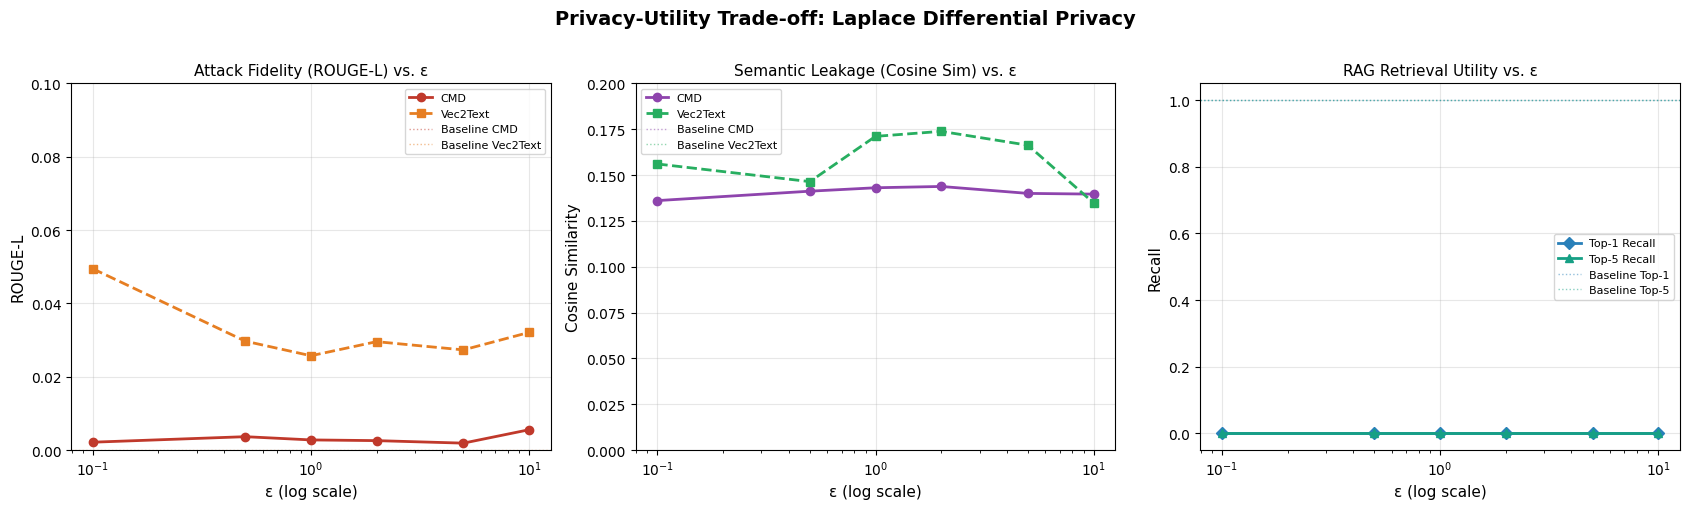

Saved: phase3_dp_frontier.png


In [15]:
eps_vals  = sorted(dp_results.keys())
cmd_rouge = [dp_results[e]['cmd']['rougeL']            for e in eps_vals]
v2t_rouge = [dp_results[e]['vec2text']['rougeL']       for e in eps_vals]
cmd_cos   = [dp_results[e]['cmd']['cos_sim']           for e in eps_vals]
v2t_cos   = [dp_results[e]['vec2text']['cos_sim']      for e in eps_vals]
ret_top1  = [dp_results[e]['retrieval']['top1_recall'] for e in eps_vals]
ret_top5  = [dp_results[e]['retrieval']['top5_recall'] for e in eps_vals]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Privacy-Utility Trade-off: Laplace Differential Privacy', fontsize=14, fontweight='bold', y=1.01)

# ROUGE-L
ax = axes[0]
ax.plot(eps_vals, cmd_rouge, 'o-', color='#c0392b', lw=2, label='CMD')
ax.plot(eps_vals, v2t_rouge, 's--', color='#e67e22', lw=2, label='Vec2Text')
ax.axhline(baseline_cmd_m['rougeL'], color='#c0392b', lw=1, ls=':', alpha=0.5, label='Baseline CMD')
ax.axhline(baseline_v2t_m['rougeL'], color='#e67e22', lw=1, ls=':', alpha=0.5, label='Baseline Vec2Text')
ax.set_xlabel('ε (log scale)', fontsize=11); ax.set_ylabel('ROUGE-L', fontsize=11)
ax.set_title('Attack Fidelity (ROUGE-L) vs. ε', fontsize=11)
ax.set_xscale('log'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.1)

# Cosine Sim
ax2 = axes[1]
ax2.plot(eps_vals, cmd_cos, 'o-', color='#8e44ad', lw=2, label='CMD')
ax2.plot(eps_vals, v2t_cos, 's--', color='#27ae60', lw=2, label='Vec2Text')
ax2.axhline(baseline_cmd_m['cos_sim'], color='#8e44ad', lw=1, ls=':', alpha=0.5, label='Baseline CMD')
ax2.axhline(baseline_v2t_m['cos_sim'], color='#27ae60', lw=1, ls=':', alpha=0.5, label='Baseline Vec2Text')
ax2.set_xlabel('ε (log scale)', fontsize=11); ax2.set_ylabel('Cosine Similarity', fontsize=11)
ax2.set_title('Semantic Leakage (Cosine Sim) vs. ε', fontsize=11)
ax2.set_xscale('log'); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 0.2)

# Retrieval
ax3 = axes[2]
ax3.plot(eps_vals, ret_top1, 'D-', color='#2980b9', lw=2, label='Top-1 Recall')
ax3.plot(eps_vals, ret_top5, '^-', color='#16a085', lw=2, label='Top-5 Recall')
ax3.axhline(baseline_ret['top1_recall'], color='#2980b9', lw=1, ls=':', alpha=0.5, label='Baseline Top-1')
ax3.axhline(baseline_ret['top5_recall'], color='#16a085', lw=1, ls=':', alpha=0.5, label='Baseline Top-5')
ax3.set_xlabel('ε (log scale)', fontsize=11); ax3.set_ylabel('Recall', fontsize=11)
ax3.set_title('RAG Retrieval Utility vs. ε', fontsize=11)
ax3.set_xscale('log'); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase3_dp_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase3_dp_frontier.png')

### 3.6.2 All-Metrics × ε Heatmap

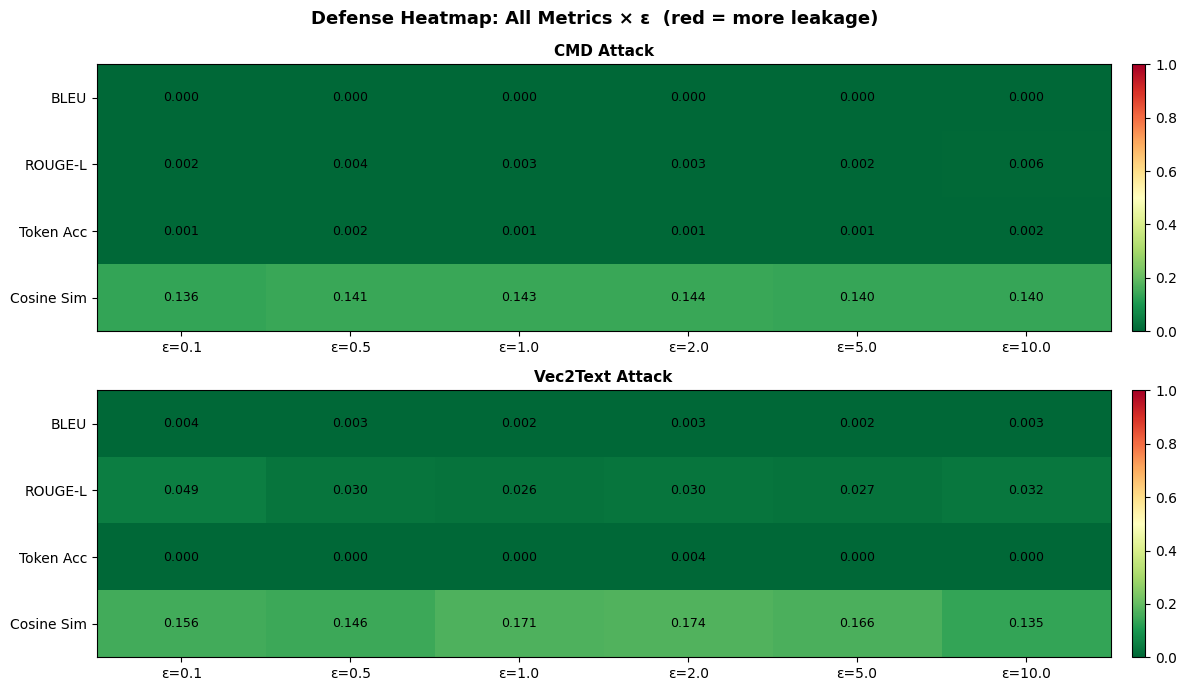

Saved: phase3_heatmap.png


In [19]:
metric_keys   = ['bleu', 'rougeL', 'tok_acc', 'cos_sim']
metric_labels = ['BLEU', 'ROUGE-L', 'Token Acc', 'Cosine Sim']

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
fig.suptitle('Defense Heatmap: All Metrics × ε  (red = more leakage)', fontsize=13, fontweight='bold')

for ax_i, (attack_key, attack_label) in enumerate([('cmd', 'CMD'), ('vec2text', 'Vec2Text')]):
    data = np.array([[dp_results[e][attack_key][m] for e in eps_vals] for m in metric_keys])
    im   = axes[ax_i].imshow(data, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[ax_i].set_xticks(range(len(eps_vals)))
    axes[ax_i].set_xticklabels([f'ε={e}' for e in eps_vals], fontsize=10)
    axes[ax_i].set_yticks(range(len(metric_labels)))
    axes[ax_i].set_yticklabels(metric_labels, fontsize=10)
    axes[ax_i].set_title(f'{attack_label} Attack', fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=axes[ax_i], fraction=0.03, pad=0.02)
    for r in range(len(metric_keys)):
        for c in range(len(eps_vals)):
            axes[ax_i].text(c, r, f'{data[r,c]:.3f}', ha='center', va='center', fontsize=9,
                             color='white' if data[r,c] > 0.6 else 'black')

plt.tight_layout()
plt.savefig('phase3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase3_heatmap.png')

### 3.6.3 Quantization Bar Chart

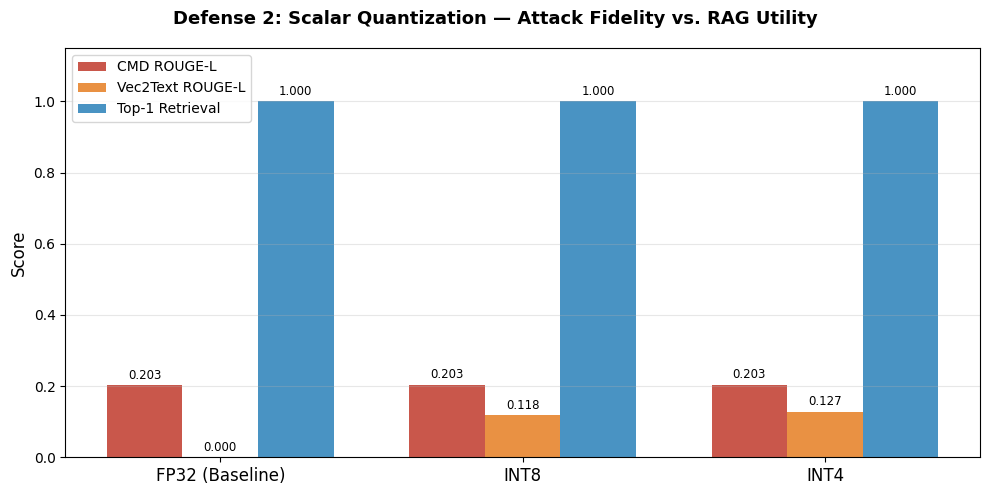

Saved: phase3_quantization.png


In [20]:
configs    = ['FP32 (Baseline)', 'INT8', 'INT4']
cmd_r      = [baseline_cmd_m['rougeL'], quant_results[8]['cmd']['rougeL'],      quant_results[4]['cmd']['rougeL']]
v2t_r      = [baseline_v2t_m['rougeL'], quant_results[8]['vec2text']['rougeL'], quant_results[4]['vec2text']['rougeL']]
ret_top1s  = [baseline_ret['top1_recall'], quant_results[8]['retrieval']['top1_recall'], quant_results[4]['retrieval']['top1_recall']]

x, w = np.arange(len(configs)), 0.25
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Defense 2: Scalar Quantization — Attack Fidelity vs. RAG Utility', fontsize=13, fontweight='bold')

b1 = ax.bar(x - w,  cmd_r,     w, label='CMD ROUGE-L',      color='#c0392b', alpha=0.85)
b2 = ax.bar(x,      v2t_r,     w, label='Vec2Text ROUGE-L', color='#e67e22', alpha=0.85)
b3 = ax.bar(x + w,  ret_top1s, w, label='Top-1 Retrieval',  color='#2980b9', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(configs, fontsize=12)
ax.set_ylabel('Score', fontsize=12); ax.set_ylim(0, 1.15)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.savefig('phase3_quantization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase3_quantization.png')

### 3.6.4 Privacy Gain vs. Utility Retained — The Elbow Finder

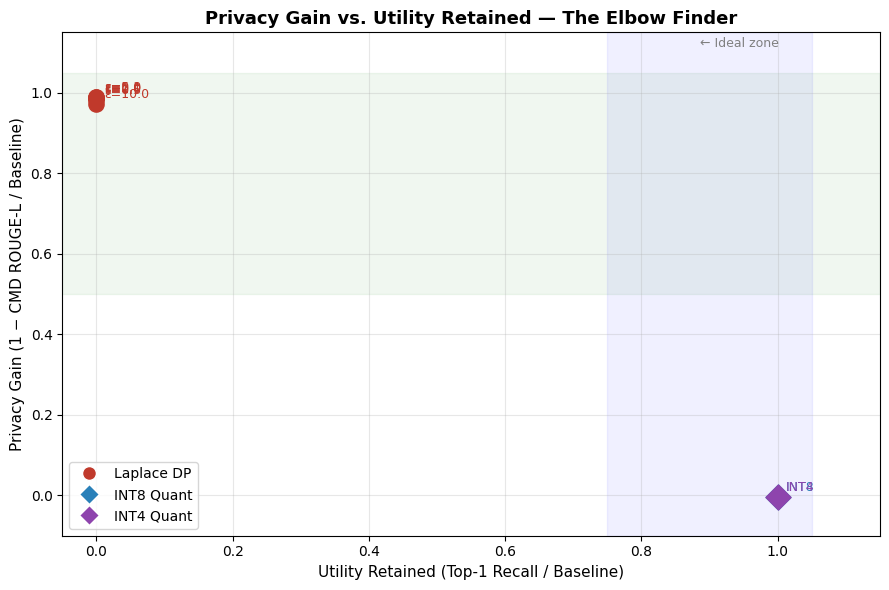

Saved: phase3_elbow.png


In [21]:
from matplotlib.lines import Line2D

base_rouge = baseline_cmd_m['rougeL']
base_r1    = baseline_ret['top1_recall']

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_title('Privacy Gain vs. Utility Retained — The Elbow Finder', fontsize=13, fontweight='bold')

# Laplace DP points
for eps in eps_vals:
    r    = dp_results[eps]
    util = r['retrieval']['top1_recall']  / max(base_r1,    1e-6)
    priv = 1 - r['cmd']['rougeL']         / max(base_rouge, 1e-6)
    ax.scatter(util, priv, s=120, color='#c0392b', zorder=5)
    ax.annotate(f'ε={eps}', (util, priv), textcoords='offset points', xytext=(6, 4), fontsize=9, color='#c0392b')

# Quantization points
q_colors = {8: '#2980b9', 4: '#8e44ad'}
for bits in QUANTIZATION_BITS:
    r    = quant_results[bits]
    util = r['retrieval']['top1_recall'] / max(base_r1,    1e-6)
    priv = 1 - r['cmd']['rougeL']        / max(base_rouge, 1e-6)
    ax.scatter(util, priv, s=160, marker='D', color=q_colors[bits], zorder=5)
    ax.annotate(f'INT{bits}', (util, priv), textcoords='offset points', xytext=(6, 4), fontsize=9, color=q_colors[bits])

ax.axhspan(0.5, 1.05, alpha=0.06, color='green')
ax.axvspan(0.75, 1.05, alpha=0.06, color='blue')
ax.text(0.78, 0.97, '← Ideal zone', fontsize=9, color='gray', transform=ax.transAxes)

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#c0392b', markersize=10, label='Laplace DP'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor='#2980b9', markersize=10, label='INT8 Quant'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor='#8e44ad', markersize=10, label='INT4 Quant'),
]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_xlabel('Utility Retained (Top-1 Recall / Baseline)', fontsize=11)
ax.set_ylabel('Privacy Gain (1 − CMD ROUGE-L / Baseline)', fontsize=11)
ax.set_xlim(-0.05, 1.15); ax.set_ylim(-0.1, 1.15)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase3_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase3_elbow.png')

### 3.6.5 Qualitative Reconstruction Gallery
Side-by-side CMD outputs at key ε values — shows how legibility degrades with stronger noise.

In [22]:
N_SHOW  = 5
key_eps = [0.1, 1.0, 10.0]

gallery = {'Baseline': baseline_cmd_preds[:N_SHOW]}
for eps in key_eps:
    noisy = add_laplace_noise(eval_vectors[:N_SHOW], eps, sensitivity)
    gallery[f'ε={eps}'] = run_cmd_attack(noisy)

print('═'*80)
print('CMD RECONSTRUCTION GALLERY — Laplace DP at Key ε Values')
print('═'*80)
for i in range(N_SHOW):
    print(f'\n[{i+1}] ORIGINAL   : {eval_texts[i]}')
    for label, preds in gallery.items():
        print(f'    {label:<12}: {preds[i]}')
print('═'*80)

════════════════════════════════════════════════════════════════════════════════
CMD RECONSTRUCTION GALLERY — Laplace DP at Key ε Values
════════════════════════════════════════════════════════════════════════════════

[1] ORIGINAL   : Rachelle, the total cost of your dental surgery is YER 601k. You can wire the payment to account PK55PXB
    Baseline    : Hi,,, your your the the is is is.... of of can can can can the the account   QQJQ
    ε=0.1       : after after to after after after after after after after after after after after after after to to to after after to to after after after after after to to after after
    ε=1.0       : 
    ε=10.0      : Please Medical Medical Please Medical Medical Please review Please document Please Please Please Please Please document Please Please Please document review Security Security Security Security Security Security Security. Please Please

[2] ORIGINAL   : Reaching out to all personnel involved in the clinical trial. The completed forms n

## 3.7 — Comprehensive Results Table

In [23]:
rows = []

for attack, m in [('CMD', baseline_cmd_m), ('Vec2Text', baseline_v2t_m)]:
    rows.append({'Defense':'None (Baseline)','Config':'—','Attack':attack,
                 'BLEU':round(m['bleu'],4),'ROUGE-L':round(m['rougeL'],4),
                 'Token Acc':round(m['tok_acc'],4),'Cosine Sim':round(m['cos_sim'],4),
                 'Top-1 Recall':round(baseline_ret['top1_recall'],4),
                 'Top-5 Recall':round(baseline_ret['top5_recall'],4)})

for eps in eps_vals:
    ret = dp_results[eps]['retrieval']
    for attack, key in [('CMD','cmd'),('Vec2Text','vec2text')]:
        m = dp_results[eps][key]
        rows.append({'Defense':'Laplace DP','Config':f'ε={eps}','Attack':attack,
                     'BLEU':round(m['bleu'],4),'ROUGE-L':round(m['rougeL'],4),
                     'Token Acc':round(m['tok_acc'],4),'Cosine Sim':round(m['cos_sim'],4),
                     'Top-1 Recall':round(ret['top1_recall'],4),
                     'Top-5 Recall':round(ret['top5_recall'],4)})

for bits in QUANTIZATION_BITS:
    ret = quant_results[bits]['retrieval']
    for attack, key in [('CMD','cmd'),('Vec2Text','vec2text')]:
        m = quant_results[bits][key]
        rows.append({'Defense':'Quantization','Config':f'INT{bits}','Attack':attack,
                     'BLEU':round(m['bleu'],4),'ROUGE-L':round(m['rougeL'],4),
                     'Token Acc':round(m['tok_acc'],4),'Cosine Sim':round(m['cos_sim'],4),
                     'Top-1 Recall':round(ret['top1_recall'],4),
                     'Top-5 Recall':round(ret['top5_recall'],4)})

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))
results_df.to_csv('phase3_results.csv', index=False)
print('\nSaved: phase3_results.csv')

        Defense Config   Attack   BLEU  ROUGE-L  Token Acc  Cosine Sim  Top-1 Recall  Top-5 Recall
None (Baseline)      —      CMD 0.0152   0.2026     0.0746      0.3688           1.0           1.0
None (Baseline)      — Vec2Text 0.0000   0.0000     0.0000      0.6740           1.0           1.0
     Laplace DP  ε=0.1      CMD 0.0002   0.0022     0.0011      0.1361           0.0           0.0
     Laplace DP  ε=0.1 Vec2Text 0.0037   0.0494     0.0000      0.1560           0.0           0.0
     Laplace DP  ε=0.5      CMD 0.0003   0.0037     0.0016      0.1412           0.0           0.0
     Laplace DP  ε=0.5 Vec2Text 0.0030   0.0297     0.0000      0.1464           0.0           0.0
     Laplace DP  ε=1.0      CMD 0.0003   0.0028     0.0007      0.1431           0.0           0.0
     Laplace DP  ε=1.0 Vec2Text 0.0021   0.0257     0.0000      0.1711           0.0           0.0
     Laplace DP  ε=2.0      CMD 0.0002   0.0026     0.0010      0.1438           0.0           0.0
     Lapla

## 3.8 — Save All Results

In [24]:
all_results = {
    'baseline'    : {'cmd': baseline_cmd_m, 'vec2text': baseline_v2t_m, 'retrieval': baseline_ret},
    'laplace_dp'  : {str(k): v for k, v in dp_results.items()},
    'quantization': {str(k): v for k, v in quant_results.items()},
}
with open('phase3_all_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print('Phase 3 complete!\n')
print('Outputs:')
print('  phase3_all_results.json   — full metrics for every configuration')
print('  phase3_results.csv        — flat table for report / poster')
print('  phase3_dp_frontier.png    — DP frontier curves (ROUGE-L, Cosine Sim, Retrieval)')
print('  phase3_heatmap.png        — all metrics × ε heatmap (CMD and Vec2Text)')
print('  phase3_quantization.png   — quantization grouped bar chart')
print('  phase3_elbow.png          — privacy gain vs. utility retained scatter')

Phase 3 complete!

Outputs:
  phase3_all_results.json   — full metrics for every configuration
  phase3_results.csv        — flat table for report / poster
  phase3_dp_frontier.png    — DP frontier curves (ROUGE-L, Cosine Sim, Retrieval)
  phase3_heatmap.png        — all metrics × ε heatmap (CMD and Vec2Text)
  phase3_quantization.png   — quantization grouped bar chart
  phase3_elbow.png          — privacy gain vs. utility retained scatter


### RECONSTRUCTION

In [4]:
# ── Restore all variables from saved files ────────────────────────────────────

# Texts and vectors
with open('processed_pii_texts.pkl', 'rb') as f:
    texts_for_db = pickle.load(f)
vectors          = np.load('embeddings.npy').astype('float32')
N_EVAL           = 200
eval_texts       = texts_for_db[-N_EVAL:]
eval_vectors_np  = vectors[-N_EVAL:]

# Sensitivity (recompute — fast)
sensitivity = float(np.mean(np.sum(np.abs(vectors), axis=1)))

# CMD baseline from Phase 2
CMD_CKPT = './cmd_checkpoints_small'
with open(f'{CMD_CKPT}/eval_results.json') as f:
    phase2_eval = json.load(f)
baseline_cmd_m     = {
    'bleu'   : phase2_eval['confidence']['bleu'],
    'rougeL' : phase2_eval['confidence']['rougeL'],
    'tok_acc': phase2_eval['confidence']['tok_acc'],
    'cos_sim': phase2_eval['confidence']['cos_sim'],
}
baseline_cmd_preds = [s['conf_pred'] for s in phase2_eval['samples']]

# DP and quantization results
with open('dp_results_checkpoint.json') as f:
    dp_results = {float(k): v for k, v in json.load(f).items()}
with open('quant_results_checkpoint.json') as f:
    quant_results = {int(k): v for k, v in json.load(f).items()}

QUANTIZATION_BITS = [8, 4]
EPSILON_VALUES    = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
eps_vals          = sorted(dp_results.keys())

print('All variables restored. Ready to run gallery cells.')

All variables restored. Ready to run gallery cells.


In [16]:
# ── 3.6.6 Reconstruction Gallery — fixed numpy input ──────────────────────────
N_SHOW  = 5
key_eps = [0.1, 1.0, 10.0]

gallery = {'Baseline (no defense)': baseline_cmd_preds[:N_SHOW]}
for eps in key_eps:
    noisy = add_laplace_noise(eval_vectors_np[:N_SHOW], eps, sensitivity)  # numpy
    gallery[f'ε={eps}'] = run_cmd_attack(noisy)

print('═'*80)
print('CMD RECONSTRUCTION GALLERY — Laplace DP at Key ε Values')
print('═'*80)
for i in range(N_SHOW):
    print(f'\n[{i+1}] ORIGINAL : {eval_texts[i]}')
    for label, preds in gallery.items():
        print(f'    {label:<22}: {preds[i]}')
print('═'*80)

════════════════════════════════════════════════════════════════════════════════
CMD RECONSTRUCTION GALLERY — Laplace DP at Key ε Values
════════════════════════════════════════════════════════════════════════════════

[1] ORIGINAL : Rachelle, the total cost of your dental surgery is YER 601k. You can wire the payment to account PK55PXB
    Baseline (no defense) : Rachelle, total total cost the dental dental surgery is.YYYYkk You can the the the account account accountPKPKPPP
    ε=0.1                 : London London London £ £ £ £ £ £ £ £ £ £ £ £ £ £ £ £ £ £ £ £ £ £ £ £ £ £ London £ London
    ε=1.0                 : Seal Seologyologyologyologyalal Se..al.................. Se
    ε=10.0                : " A failed failed failed failed recent failed failed recent failed failed failed failed failed failed failed failed failed failed failed failed failed failed- failed-ification failed failed failed "

[2] ORIGINAL : Reaching out to all personnel involved in the clinical trial. The compl

In [19]:
# ── 3.6.7 Reconstruction Gallery — Quantization ───────────────────────────────
N_SHOW = 5

quant_gallery = {'Baseline (no defense)': baseline_cmd_preds[:N_SHOW]}
for bits in QUANTIZATION_BITS:
    quant_eval_sample = scalar_quantize(eval_vectors_np[:N_SHOW], bits)
    quant_gallery[f'INT{bits}'] = run_cmd_attack(quant_eval_sample)

print('═'*80)
print('CMD RECONSTRUCTION GALLERY — Scalar Quantization')
print('═'*80)
for i in range(N_SHOW):
    print(f'\n[{i+1}] ORIGINAL : {eval_texts[i]}')
    for label, preds in quant_gallery.items():
        print(f'    {label:<22}: {preds[i]}')
print('═'*80)

════════════════════════════════════════════════════════════════════════════════
CMD RECONSTRUCTION GALLERY — Scalar Quantization
════════════════════════════════════════════════════════════════════════════════

[1] ORIGINAL : Rachelle, the total cost of your dental surgery is YER 601k. You can wire the payment to account PK55PXB
    Baseline (no defense) : Rachelle, total total cost the dental dental surgery is.YYYYkk You can the the the account account accountPKPKPPP
    INT8                  : Rachelle, total total cost the dental dental surgery is.YYYYkk You can the the the account account accountPKPKPPP
    INT4                  : Rachelle, total total cost the dental dental surgery surgery.YYYYkk You can the the the account account accountPKPKPPB

[2] ORIGINAL : Reaching out to all personnel involved in the clinical trial. The completed forms need to be sent to Suite 237, postal code 59444-7230
    Baseline (no defense) : Reaching out to all personnel personnel out clinical clini